In [18]:
import pandas as pd
import numpy as np
import regex as re
import os

In [12]:
path = r"C:\Users\Vishnu\Desktop\Fraud_detection\Data"

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\Users\Vishnu\Desktop\Fraud_detection\Data\account_profiles.csv
C:\Users\Vishnu\Desktop\Fraud_detection\Data\fraud_patterns.csv
C:\Users\Vishnu\Desktop\Fraud_detection\Data\network_edges.csv
C:\Users\Vishnu\Desktop\Fraud_detection\Data\time_series_stats.csv
C:\Users\Vishnu\Desktop\Fraud_detection\Data\transactions.csv


In [19]:
acc_prof= pd.read_csv(r"C:\Users\Vishnu\Desktop\Fraud_detection\Data\account_profiles.csv")
fraud_p = pd.read_csv(r"C:\Users\Vishnu\Desktop\Fraud_detection\Data\fraud_patterns.csv")
net_edges = pd.read_csv(r"C:\Users\Vishnu\Desktop\Fraud_detection\Data\network_edges.csv")
tss = pd.read_csv(r"C:\Users\Vishnu\Desktop\Fraud_detection\Data\time_series_stats.csv")
trans = pd.read_csv(r"C:\Users\Vishnu\Desktop\Fraud_detection\Data\transactions.csv")

In [21]:
dfs = {'account_ profiles' : acc_prof,
       'fraud_patterns' : fraud_p,
       'network_edges' : net_edges,
       'time_series_stats' : tss,
       'transactions' : trans }

In [24]:
for name, df in dfs.items():
    print(f"==={name}===")
    print("Shape :", df.shape)
    print("Columns:", list(df.columns))
    print("Missing Values:\n", df.isnull().sum())
    print(df.info())

===account_ profiles===
Shape : (50000, 23)
Columns: ['account_id', 'account_age_days', 'credit_limit', 'home_country', 'risk_score', 'is_high_risk', 'avg_txn_amount', 'avg_monthly_txns', 'has_2fa', 'account_type', 'total_transactions', 'total_amount', 'avg_amount', 'max_amount', 'fraud_count', 'fraud_amount', 'pct_foreign', 'avg_velocity', 'unique_countries', 'unique_categories', 'avg_ip_risk', 'fraud_rate', 'is_fraudster']
Missing Values:
 account_id            0
account_age_days      0
credit_limit          0
home_country          0
risk_score            0
is_high_risk          0
avg_txn_amount        0
avg_monthly_txns      0
has_2fa               0
account_type          0
total_transactions    0
total_amount          0
avg_amount            0
max_amount            0
fraud_count           0
fraud_amount          0
pct_foreign           0
avg_velocity          0
unique_countries      0
unique_categories     0
avg_ip_risk           0
fraud_rate            0
is_fraudster          0
dt

In [32]:
features = [
    "device_known",
    "is_foreign_txn",
    "velocity_1h",
    "amount_vs_avg_ratio",
    "ip_risk_score"
]

target = "is_fraud"

In [26]:
trans = trans.sort_values("timestamp")

In [28]:
trans.head()

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
277316,TXN000277317,ACC0045807,2022-01-01 00:00:01,0,5,1,65.78,utilities,4900,US,...,21.4,0,232,1,0.5266,1773,1,3849.06,0,NaN
667823,TXN000667824,ACC0028794,2022-01-01 00:02:54,0,5,1,64.01,grocery,5411,DE,...,40.6,1,15,1,3.4563,2408,0,1742.87,0,NaN
766995,TXN000766996,ACC0005585,2022-01-01 00:03:29,0,5,1,801.70,travel,4511,DE,...,24.2,1,36,0,11.4923,1692,1,5923.23,0,NaN
525596,TXN000525597,ACC0000492,2022-01-01 00:05:39,0,5,1,352.71,hotel,7011,CA,...,34.0,1,462,0,3.8205,3171,0,3544.65,0,NaN
89981,TXN000089982,ACC0033651,2022-01-01 00:06:10,0,5,1,43.13,grocery,5411,US,...,45.4,0,184,1,0.7770,1255,0,2517.79,0,NaN


In [29]:
split_index = int(0.8 * len(trans))

train = trans.iloc[:split_index]
test = trans.iloc[split_index:]

In [33]:
x_train = train[features]
y_train = train[target]

x_test = test[features]
y_test = test[target]


In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = Scaler.fit_transform(x_train)
x_test_scaled = Scaler.transform(x_test)


In [66]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x_train_scaled, y_train)

In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight= "balanced")
model.fit(x_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [69]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring='roc_auc')
print("CV ROC-AUC:", scores.mean())

CV ROC-AUC: 0.9882003726094984


In [47]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(x_test_scaled)[:, 1]

probs = model.predict_proba(x_test_scaled)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, probs))

ROC-AUC: 0.9875812429189936


In [50]:
y_pred = (y_pred_proba > 0.5).astype(int)

In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[185524,  11072],
       [   208,   3196]], dtype=int64)

In [54]:
from sklearn.metrics import precision_score, recall_score
for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_pred_proba >i).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print("Precision:", precision)
    print("Recall:", recall)

Precision: 0.2239977572189515
Recall: 0.9388954171562868
Precision: 0.2239977572189515
Recall: 0.9388954171562868
Precision: 0.2239977572189515
Recall: 0.9388954171562868
Precision: 0.2239977572189515
Recall: 0.9388954171562868
Precision: 0.2239977572189515
Recall: 0.9388954171562868
Precision: 0.2239977572189515
Recall: 0.9388954171562868
Precision: 0.2239977572189515
Recall: 0.9388954171562868


In [57]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators = 650,
    max_depth= 6,
    learning_rate = 0.05,
    subsample=0.8,
    colsample_bytree= 0.8,
    random_state = 42
)

model.fit(x_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

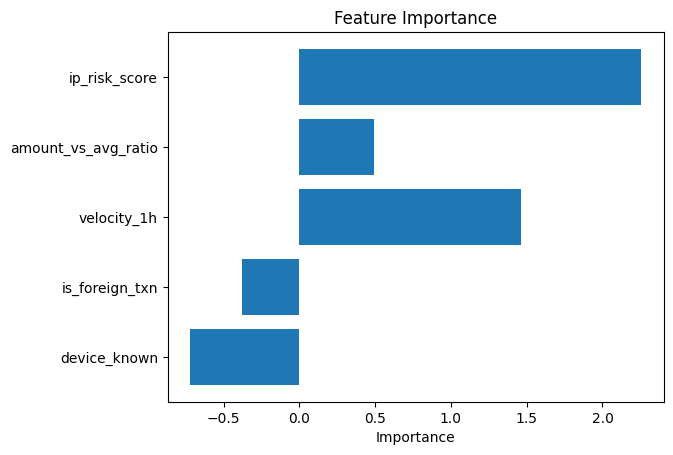

In [78]:
import matplotlib.pyplot as plt

importance = model.coef_[0]

plt.barh(features,importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [59]:
probs = model.predict_proba(x_test_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, probs))

ROC-AUC: 0.9926008937390531


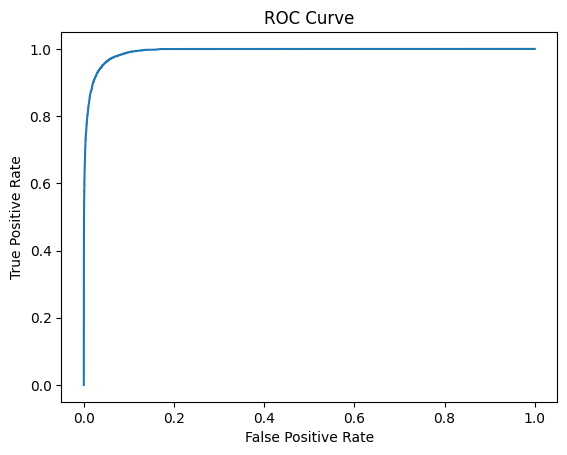

In [70]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

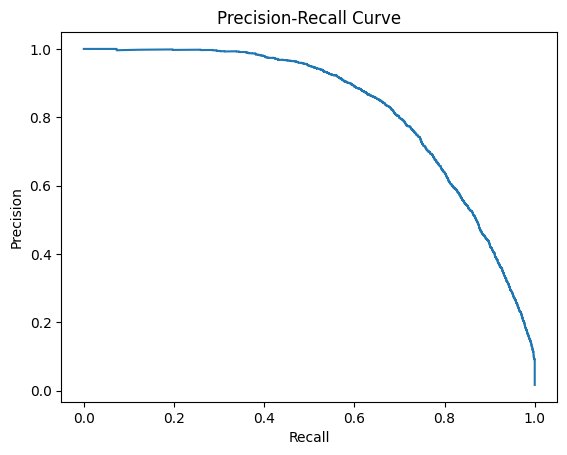

In [71]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [79]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    preds = (probs > t).astype(int)
    print(f"Threshold: {t:.2f}, F1-score: {f1_score(y_test, preds):.4f}")

Threshold: 0.10, F1-score: 0.6447
Threshold: 0.15, F1-score: 0.6826
Threshold: 0.20, F1-score: 0.7095
Threshold: 0.25, F1-score: 0.7268
Threshold: 0.30, F1-score: 0.7363
Threshold: 0.35, F1-score: 0.7447
Threshold: 0.40, F1-score: 0.7460
Threshold: 0.45, F1-score: 0.7454
Threshold: 0.50, F1-score: 0.7437
Threshold: 0.55, F1-score: 0.7357
Threshold: 0.60, F1-score: 0.7244
Threshold: 0.65, F1-score: 0.7120
Threshold: 0.70, F1-score: 0.6987
Threshold: 0.75, F1-score: 0.6807
Threshold: 0.80, F1-score: 0.6584
Threshold: 0.85, F1-score: 0.6306


# Save Model 

In [82]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [83]:
joblib.dump(model, "fraud_model.pkl")

['fraud_model.pkl']

In [86]:
import joblib
model = joblib.load("fraud_model.pkl")